# UA2 · Clase NumPy — Imágenes paso a paso (con Matplotlib y Seaborn)

**Objetivo:** entender **NumPy** como base del procesamiento de imágenes: arrays, `shape`/`dtype`, slicing, selección por máscaras, operaciones vectorizadas y **histogramas** con Matplotlib y Seaborn.

**Qué necesitas:**
- Python 3.10–3.13 en un _venv/conda_ activo.
- Librerías: `numpy`, `pillow`, `matplotlib`, `seaborn`.

```bash
pip install numpy pillow matplotlib seaborn
```
_Tip VS Code:_ `M` (Markdown) · `Y` (Code) · `A/B` (celda arriba/abajo) · `Shift+Enter` (ejecuta y avanza).

In [1]:
pip install numpy pillow matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 0) Preparar imágenes de trabajo (o usa las tuyas)
Si ya tienes `UA2_vision_example.png` o `UA2_landscape_example.jpg`, déjalas junto a este notebook.
Si no, genera un **gradiente** y un **tablero** simples para pruebas:

---
## 1) Imagen → array NumPy
**Idea:** un `ndarray` es la forma natural de representar una imagen en memoria.
Trabajaremos con una imagen RGB (3 canales).

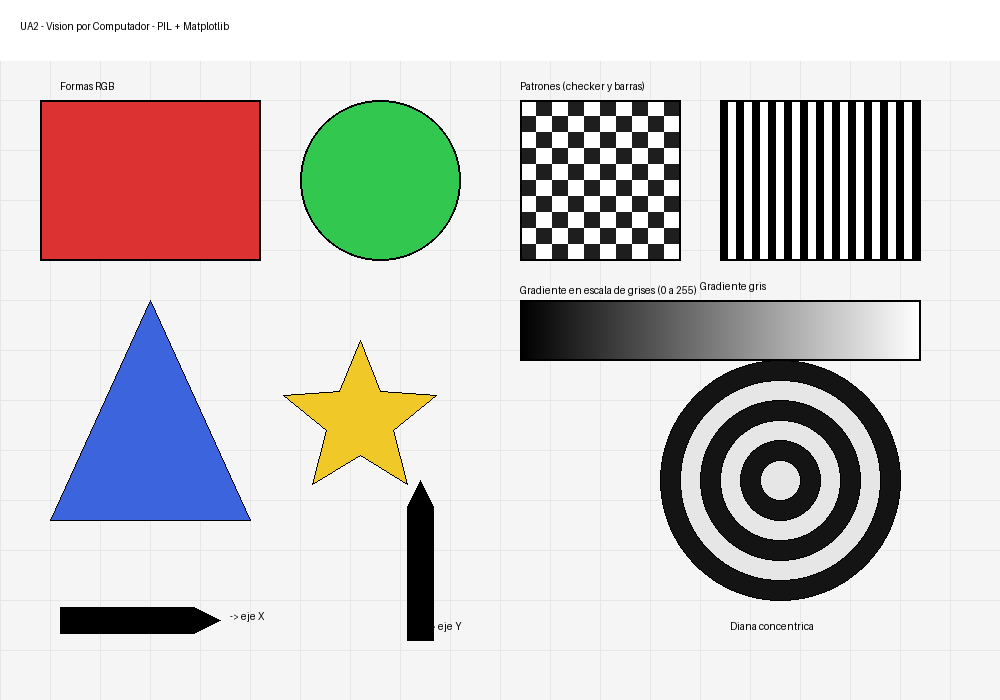

In [1]:
# FASE 1.1 — Abrir imagen con Pillow y convertir a RGB
from PIL import Image
IMG_PATH = 'UA2_vision_example.png'  # cambia por 'UA2_landscape_example.jpg' o tus archivos
img = Image.open(IMG_PATH).convert('RGB')
img

In [4]:
# FASE 1.2 — A NumPy: tipo, shape y dtype
import numpy as np
a = np.array(img)  # copia los datos a un ndarray
print(type(a))      # numpy.ndarray
print('shape:', a.shape)  # (alto, ancho, canales)
print('dtype :', a.dtype) # normalmente uint8 (0..255)

<class 'numpy.ndarray'>
shape: (700, 1000, 3)
dtype : uint8


**Comentario:**
- `shape` típico: `(H, W, 3)` para RGB.
- `dtype` `uint8` ⇒ cada canal va de 0 a 255.
- Si tu imagen tenía alfa (RGBA), al convertir a RGB quitamos el canal A (transparencia).

## 2) Acceder al valor de un píxel
**Idea:** índice como `a[fila, columna]` y añade canal si quieres un componente: `a[y, x, canal]`.

In [5]:
# FASE 2.1 — Leer un píxel y sus 3 canales
y, x = 50, 80
px = a[y, x]            # vector RGB
r, g, b = a[y, x, 0], a[y, x, 1], a[y, x, 2]
print('Pixel en (y=', y, ', x=', x, '):', px)
print('R=', r, ' G=', g, ' B=', b)

Pixel en (y= 50 , x= 80 ): [255 255 255]
R= 255  G= 255  B= 255


_Tip:_ en imágenes, el primer índice es **fila (y)**, el segundo es **columna (x)**.

## 3) Slicing y canales
**Idea:** con _slicing_ seleccionas regiones y con `:`/`...` navegas dimensiones.

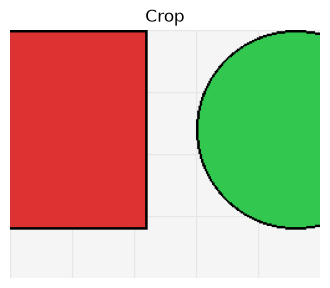

In [6]:
# FASE 3.1 — Recorte rápido con slicing
crop = a[100:300, 150:400, :]  # filas 100..299, cols 150..399, todos los canales
from matplotlib import pyplot as plt
plt.figure(figsize=(4,4)); plt.imshow(crop); plt.axis('off'); plt.title('Crop'); plt.show()

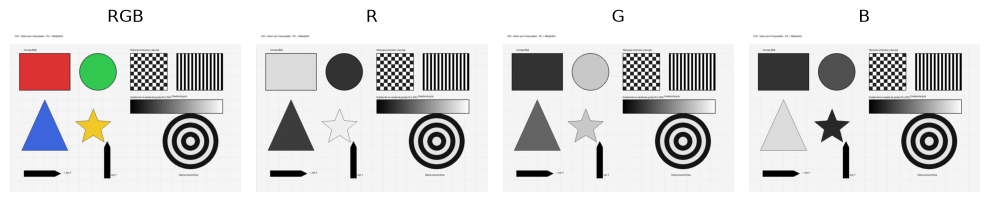

In [7]:
# FASE 3.2 — Separar canales R, G, B
R = a[:, :, 0]
G = a[:, :, 1]
B = a[:, :, 2]       # equivalente: a[..., 2]
fig, ax = plt.subplots(1,4, figsize=(10,3))
ax[0].imshow(a); ax[0].set_title('RGB'); ax[0].axis('off')
ax[1].imshow(R, cmap='gray'); ax[1].set_title('R'); ax[1].axis('off')
ax[2].imshow(G, cmap='gray'); ax[2].set_title('G'); ax[2].axis('off')
ax[3].imshow(B, cmap='gray'); ax[3].set_title('B'); ax[3].axis('off')
plt.tight_layout(); plt.show()

_Atajo:_ `a[...,2]` significa “todas las dimensiones menos la última, en 2”. Útil cuando no sabes cuántos ejes hay.

## 4) Operaciones vectorizadas (sin bucles)
**Idea:** NumPy aplica operaciones a **todos** los píxeles a la vez (rápido y claro).

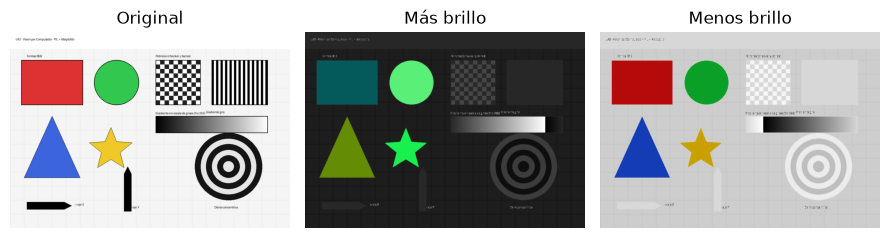

In [9]:
# FASE 4.1 — Aclarar/oscurecer (suma/resta) con clipping 0..255
brighter = np.clip(a + 40, 0, 255).astype(np.uint8)
darker   = np.clip(a - 40, 0, 255).astype(np.uint8)
fig, ax = plt.subplots(1,3, figsize=(9,3))
ax[0].imshow(a); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(brighter); ax[1].set_title('Más brillo'); ax[1].axis('off')
ax[2].imshow(darker); ax[2].set_title('Menos brillo'); ax[2].axis('off')
plt.tight_layout(); plt.show()

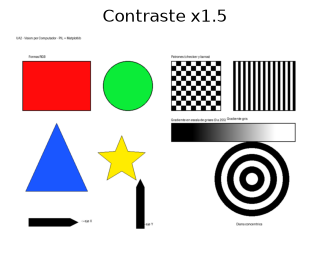

In [10]:
# FASE 4.2 — Escalado de contraste alrededor del 128
a16 = a.astype(np.int16)
contraste = np.clip( (a16-128)*1.5 + 128, 0, 255).astype(np.uint8)
plt.figure(figsize=(4,4)); plt.imshow(contraste); plt.axis('off'); plt.title('Contraste x1.5'); plt.show()

## 5) Máscaras y selección booleana
**Idea:** crea una máscara booleana (`True/False`) y úsala para seleccionar píxeles.

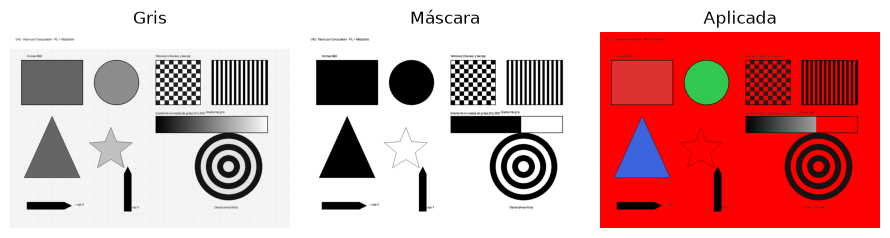

In [ ]:
# FASE 5.1 — Umbral en gris y colorear la región True
gray = np.dot(a[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)  # pasar a grices usando formula luminancia
mask = gray > 160
res = a.copy() # copy altrimenti si da solo referenza ad a e no una copia
res[mask] = [255, 0, 0]  # pinta de rojo donde mask==True
fig, ax = plt.subplots(1,3, figsize=(9,3))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Gris'); ax[0].axis('off')
ax[1].imshow(mask, cmap='gray'); ax[1].set_title('Máscara'); ax[1].axis('off')
ax[2].imshow(res); ax[2].set_title('Aplicada'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 6) Histogramas con NumPy + Matplotlib
**Idea:** `np.histogram` devuelve cuentas y bordes de bins.

Cuenta en intensidad 128: 60


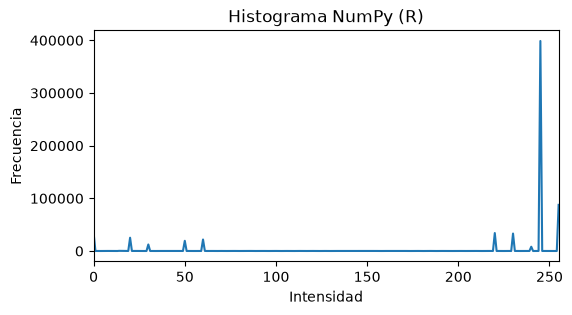

In [12]:
# FASE 6.1 — Histograma del canal R con NumPy
counts, bins = np.histogram(R, bins=256, range=(0,255))
print('Cuenta en intensidad 128:', counts[128])
plt.figure(figsize=(6,3))
plt.plot(counts)
plt.xlim(0,255); plt.xlabel('Intensidad'); plt.ylabel('Frecuencia'); plt.title('Histograma NumPy (R)')
plt.show()

## 7) Histogramas combinados con Seaborn (opcional)
**Idea:** superponer R, G y B en una sola figura.

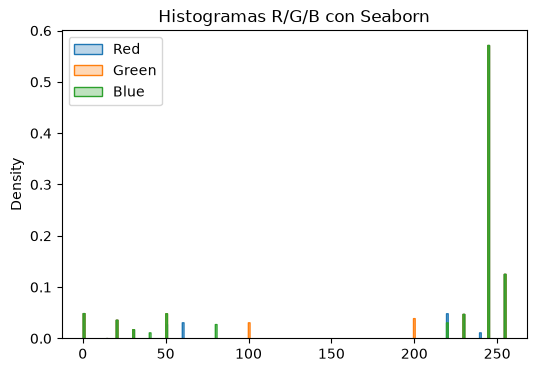

In [13]:
# FASE 7.1 — Usar seaborn.histplot
import seaborn as sns
plt.figure(figsize=(6,4))
for ch, name in [(R,'Red'), (G,'Green'), (B,'Blue')]:
    sns.histplot(ch.ravel(), bins=256, binrange=(0,255), stat='density', element='step', fill=True, alpha=0.3, label=name)
plt.legend(); plt.title('Histogramas R/G/B con Seaborn'); plt.show()

## 8) Crear imágenes desde NumPy (mini-fábrica de patrones)
**Idea:** piensa en imágenes como **matrices**.

C:\Users\chris\AppData\Local\Temp\ipykernel_45000\2426757632.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(rgb, 'RGB').save('np_gradiente.png')


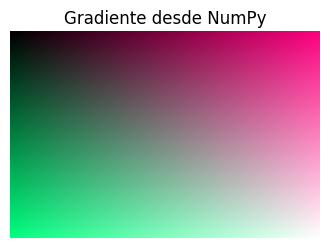

In [12]:
# FASE 8.1 — Gradiente 2D y guardar como PNG
H, W = 200, 300
gx = np.tile(np.linspace(0,255,W, dtype=np.uint8), (H,1))
gy = np.tile(np.linspace(0,255,H, dtype=np.uint8).reshape(H,1), (1,W))
rgb = np.dstack([gx, gy, (gx//2+gy//2)])
Image.fromarray(rgb, 'RGB').save('np_gradiente.png')
plt.figure(figsize=(4,3)); plt.imshow(rgb); plt.axis('off'); plt.title('Gradiente desde NumPy'); plt.show()

## 9) Buenas prácticas con NumPy (rápido)
- **Evita bucles** Python; prefiere operaciones vectorizadas.
- Cuida `dtype`: trabaja en `int16/float32` cuando hagas aritmética, vuelve a `uint8` al guardar.
- **Views vs copies**: `a[:, :100]` es una *view* (no copia). Usa `copy()` si vas a modificar sin afectar al original.
- **Broadcasting**: permite operar arrays de formas compatibles (ej. restar un valor por canal).

## 10) Mini-reto
1) Carga tu imagen.
2) Separa canales y muestra R/G/B.
3) Mejora el contraste con una fórmula vectorizada.
4) Pinta en verde (0,255,0) las zonas con luminancia `< 60` usando una máscara.
5) Guarda el resultado y compara histogramas con Matplotlib o Seaborn.

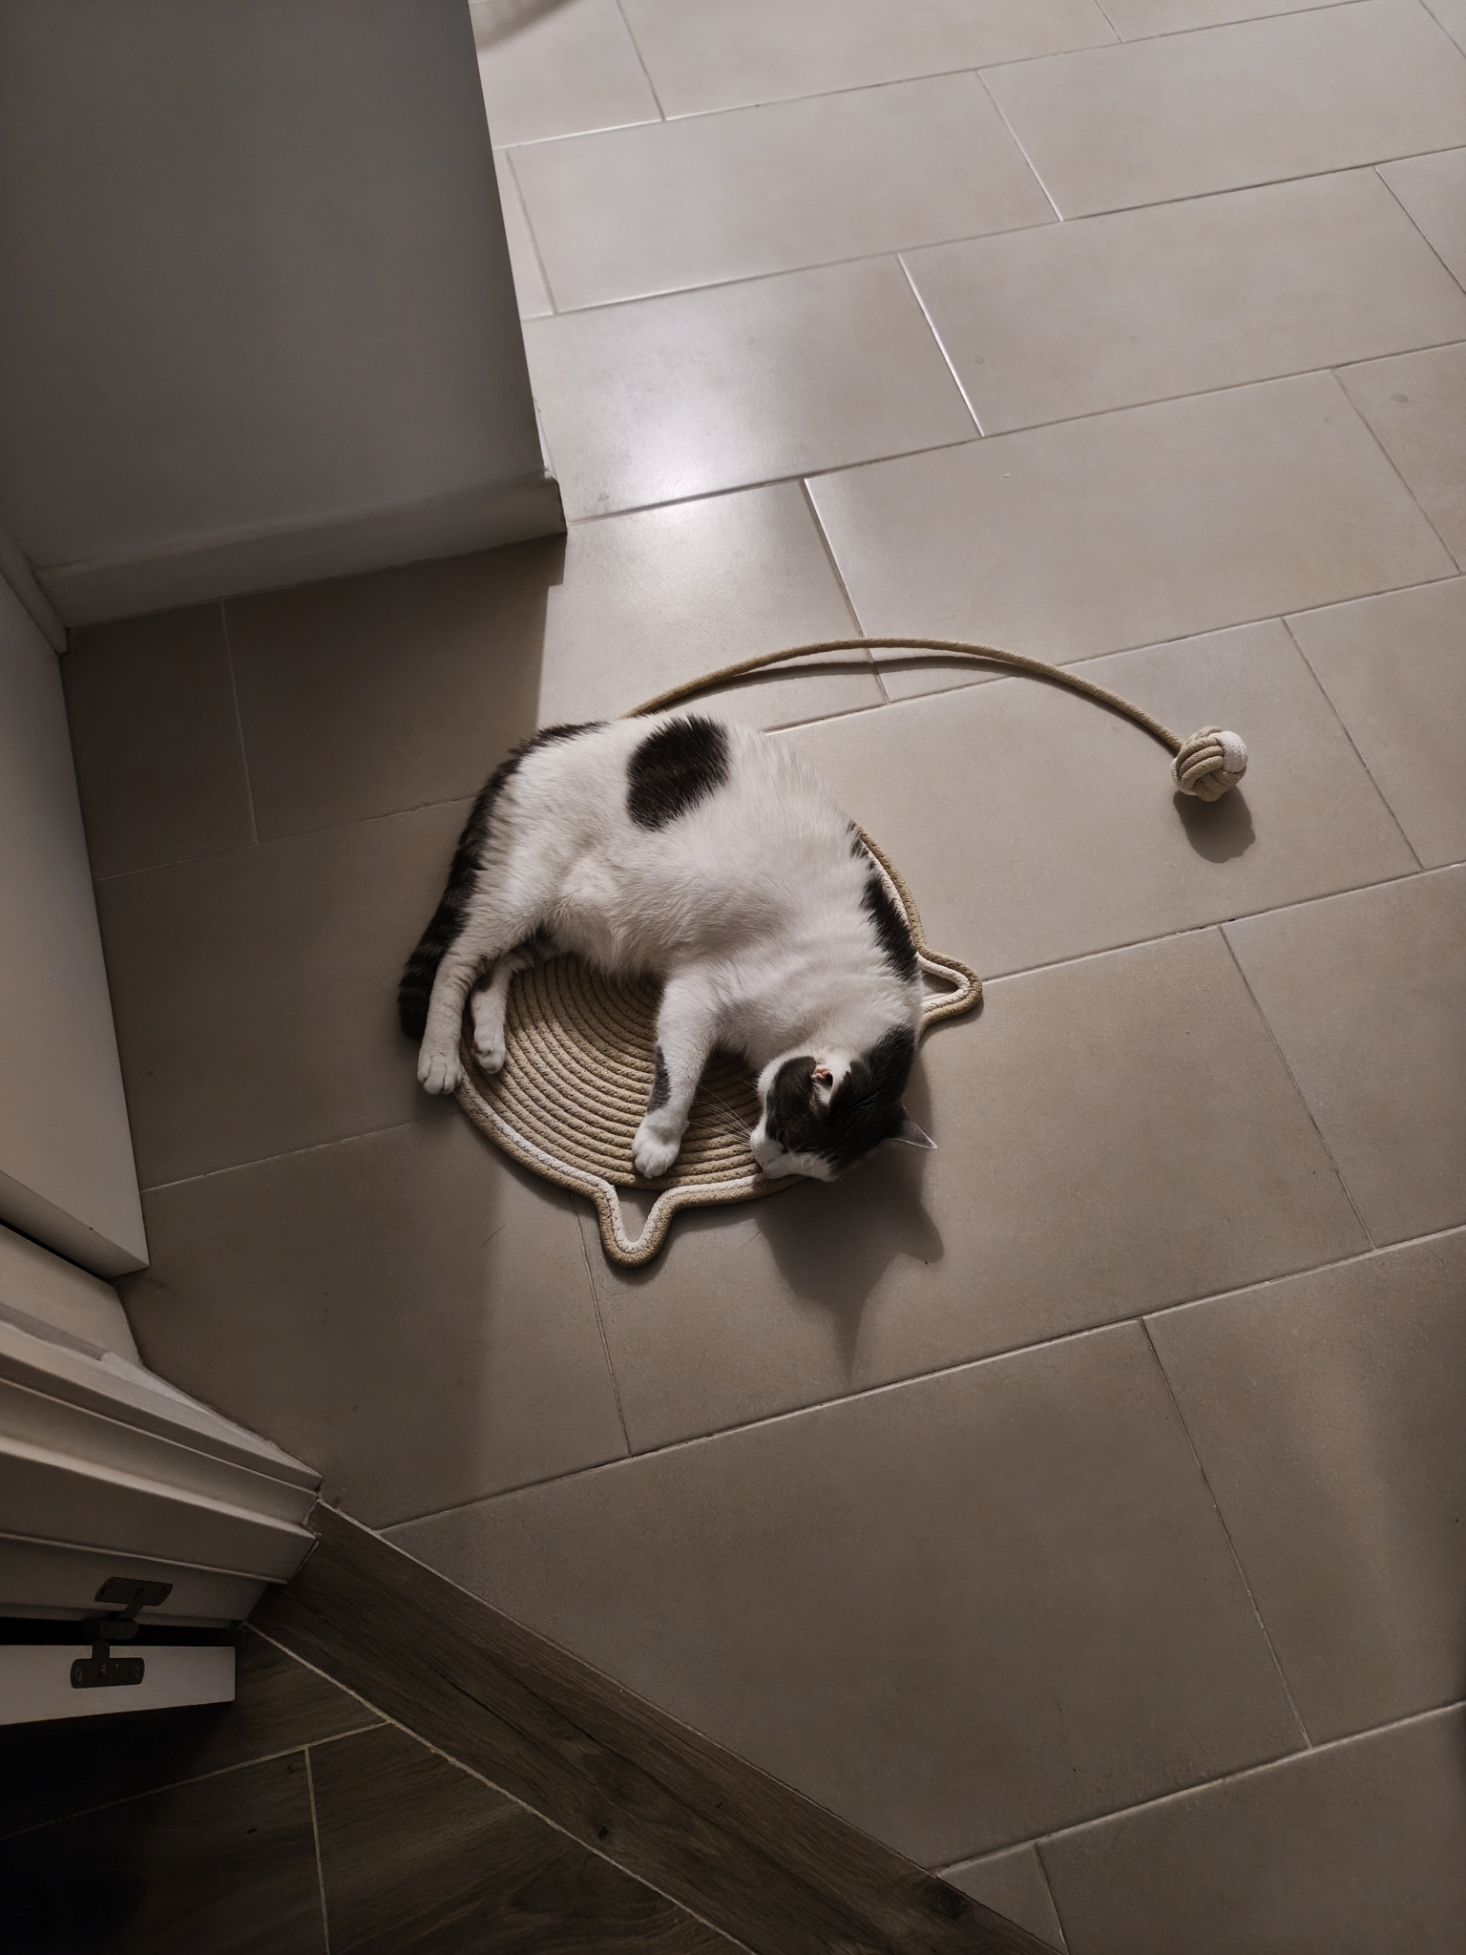

In [14]:
# Paso 1 — Abrir imagen con Pillow y convertir a RGB
from PIL import Image
IMG_PATH = 'Gatto.Jpg'  # cambia por 'UA2_landscape_example.jpg' o tus archivos
img = Image.open(IMG_PATH).convert('RGB')
img

<class 'numpy.ndarray'>
shape: (1955, 1466, 3)
dtype : uint8


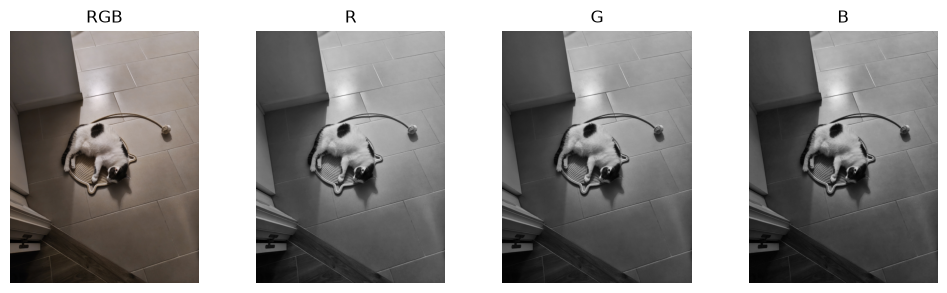

In [ ]:
# Paso 2 — Separar los canales R, G, B
import numpy as np
a = np.array(img)  # copia los datos a un ndarray
print(type(a))      # numpy.ndarray
print('shape:', a.shape)  # (alto, ancho, canales)
print('dtype :', a.dtype) # normalmente uint8 (0..255)

R = a[:, :, 0]
G = a[:, :, 1]
B = a[:, :, 2]       # equivalente: a[..., 2]
fig, ax = plt.subplots(1,4, figsize=(10,3))
ax[0].imshow(a); ax[0].set_title('RGB'); ax[0].axis('off')
ax[1].imshow(R, cmap='gray'); ax[1].set_title('R'); ax[1].axis('off')
ax[2].imshow(G, cmap='gray'); ax[2].set_title('G'); ax[2].axis('off')
ax[3].imshow(B, cmap='gray'); ax[3].set_title('B'); ax[3].axis('off')
plt.tight_layout(); plt.show()

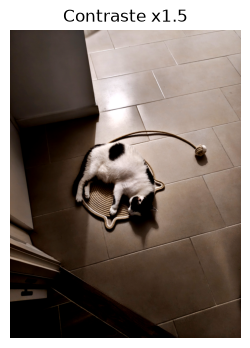

In [18]:
# Paso 3 — Mejora el contraste con una fórmula vectorizada.
a16 = a.astype(np.int16)
contraste = np.clip( (a16-128)*1.5 + 128, 0, 255).astype(np.uint8)
plt.figure(figsize=(4,4)); plt.imshow(contraste); plt.axis('off'); plt.title('Contraste x1.5'); plt.show()

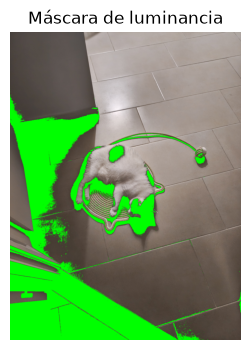

In [19]:
# Paso 4 - Pinta en verde (0,255,0) las zonas con luminancia `< 60` usando una máscara.
gray = np.dot(a[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)
mask = gray < 60
res = a.copy()
res[mask] = [0, 255, 0]  # pintar en verde las zonas con luminancia < 60
plt.figure(figsize=(4,4)); plt.imshow(res); plt.axis('off'); plt.title('Máscara de luminancia'); plt.show()

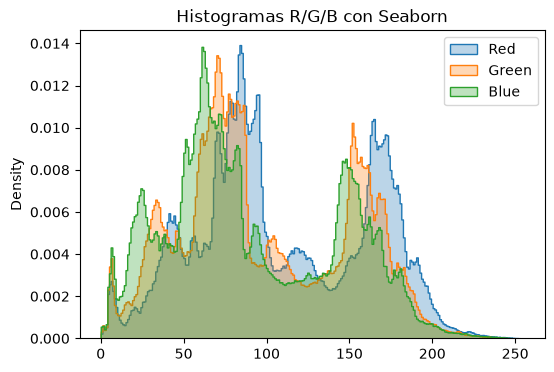

In [20]:
# Paso 5 - Guarda el resultado y compara histogramas con Matplotlib o Seaborn.
import seaborn as sns
plt.figure(figsize=(6,4))
for ch, name in [(R,'Red'), (G,'Green'), (B,'Blue')]:
    sns.histplot(ch.ravel(), bins=256, binrange=(0,255), stat='density', element='step', fill=True, alpha=0.3, label=name)
plt.legend(); plt.title('Histogramas R/G/B con Seaborn'); plt.show()

In [ ]:
# Paso 5.1: Histogramas por canal con PIL.histogram()

# r, g, b = img_rgb.split()

hist_r = img_rgb.getchannel("R").histogram()
hist_g = img_rgb.getchannel("G").histogram()
hist_b = img_rgb.getchannel("B").histogram()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(hist_r, bins=256, range=(0, 256), color="red", alpha=0.8)
axes[0].set_title("Histograma R")
axes[0].set_ylabel("Pixel")
axes[0].set_xlabel("Intensidad")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 5)

axes[1].hist(hist_g, bins=256, range=(0, 256), color="green", alpha=0.8)
axes[1].set_title("Histograma G")
axes[1].set_ylabel("Pixel")
axes[1].set_xlabel("Intensidad")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 5)

axes[2].hist(hist_b, bins=256, range=(0, 256), color="blue", alpha=0.8)
axes[2].set_title("Histograma B")
axes[2].set_ylabel("Pixel")
axes[2].set_xlabel("Intensidad")
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.bar(range(256), hist_r); plt.title("Histograma R"); plt.xlim(0,255); plt.xlabel("Intensidad"); plt.ylabel("Pixeles"); plt.show()
